In [1]:
from astropy.io import fits
import pandas as pd
from astropy.coordinates import SkyCoord
import astropy.units as u
import matplotlib.pyplot as plt
import numpy as np
import scienceplots

plt.style.use('science')

In [2]:
z_df = pd.read_csv('sheets/crossmatched.csv')
flagz_df = pd.read_csv('sheets/filtered_flagz.csv')
gauss_df = pd.read_csv('sheets/A2142_gaussian.csv')
df = pd.read_csv('sheets/2D_Gauss_dist_timesc.csv')

red = fits.open('data/L1/stack_3095663.fit')
blue = fits.open('data/L1/stack_3095664.fit')
fibtable = red[6].data  # fibre table metadata, same in blue and red

nspec_folder = 'nspec_cutred'
sheets_folder = 'sheets'

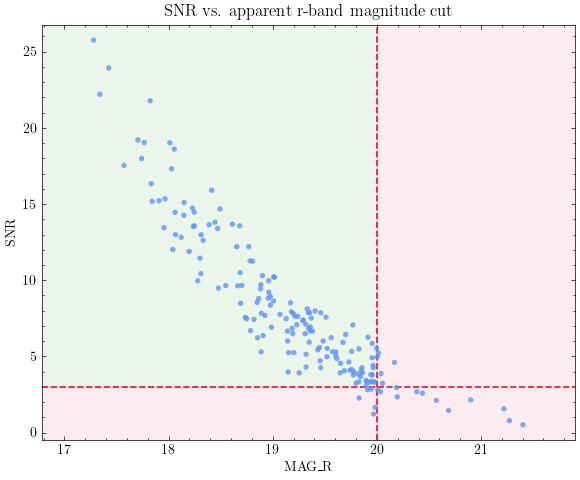

In [7]:
fig, ax = plt.subplots(figsize=(6, 5))

mag = gauss_df['MAG_R']
snr = gauss_df['SNR_RED']

ax.scatter(mag, snr, s=15, alpha=0.8, color='cornflowerblue', edgecolors='none', zorder=3)

# Fill regions
xlim = (mag.min() - 0.5, mag.max() + 0.5)
ylim_low  = ax.get_ylim()[0] if ax.get_ylim()[0] else snr.min() - 1

ax.axvline(20, color='crimson', lw=1.2, ls='--')
ax.axhline(3,  color='crimson', lw=1.2, ls='--')

# Bad region: MAG_R > 20 OR SNR < 3
ax.fill_between([20, mag.max() + 1], snr.min() - 1, snr.max() + 1, color='crimson', alpha=0.08, zorder=0)
ax.fill_between([mag.min() - 1, 20], snr.min() - 1, 3, color='crimson', alpha=0.08, zorder=0)

# Good region: MAG_R <= 20 AND SNR >= 3
ax.fill_between([mag.min() - 1, 20], 3, snr.max() + 1, color='green', alpha=0.08, zorder=0)

ax.set_xlim(mag.min() - 0.5, mag.max() + 0.5)
ax.set_ylim(snr.min() - 1, snr.max() + 1)

ax.set_title('SNR vs. apparent r-band magnitude cut')
ax.set_xlabel('MAG_R')
ax.set_ylabel('SNR')

plt.tight_layout()
plt.savefig(f'plots/SNR_vs_MAG_R.pdf', dpi=150)
plt.show()

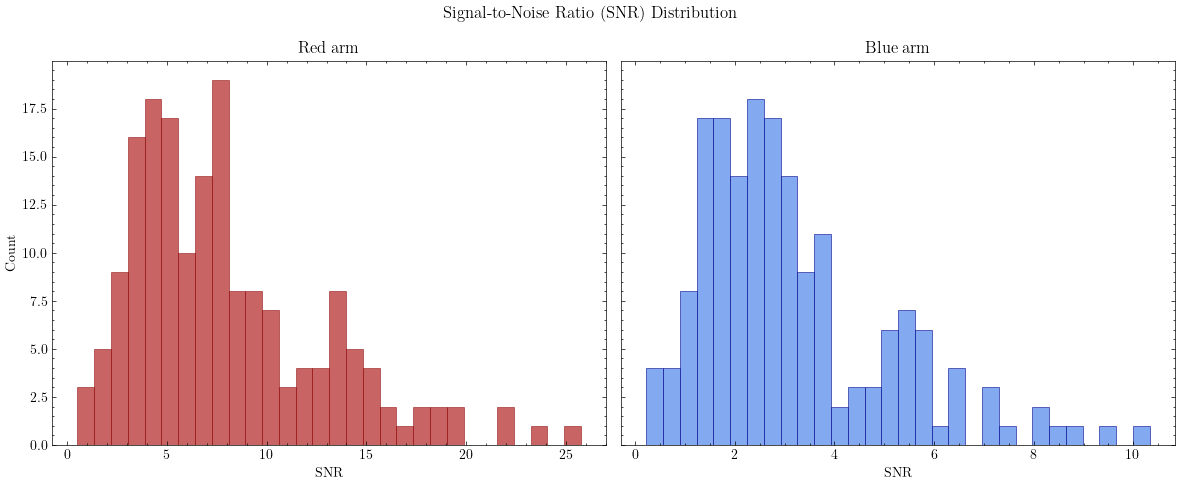

In [8]:
snr_red = gauss_df['SNR_RED'].values
snr_blue = gauss_df['SNR_BLUE'].values

fig, axes = plt.subplots(1, 2, figsize=(12, 5), sharey=True)

axes[0].hist(snr_red, bins=30, color='firebrick', alpha=0.7, edgecolor='darkred', lw=0.5)
axes[0].set_xlabel('SNR')
axes[0].set_ylabel('Count')
axes[0].set_title('Red arm')

axes[1].hist(snr_blue, bins=30, color='cornflowerblue', alpha=0.8, edgecolor='darkblue', lw=0.5)
axes[1].set_xlabel('SNR')
axes[1].set_title('Blue arm')

fig.suptitle('Signal-to-Noise Ratio (SNR) Distribution')
plt.tight_layout()
plt.savefig(f'plots/SNR_hist.pdf')
plt.show()

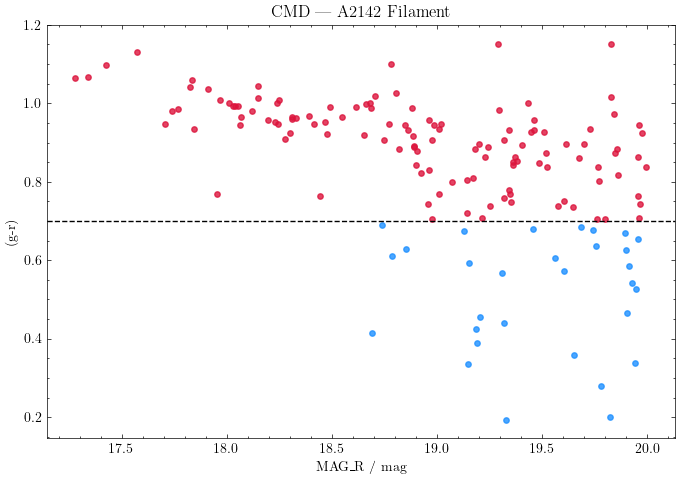

In [9]:
g_minus_r = df['MAG_G'] - df['MAG_R']
is_red = g_minus_r >= 0.7

fig, ax = plt.subplots(figsize=(7, 5))

ax.scatter(df.loc[~is_red, 'MAG_R'], g_minus_r[~is_red], s=15, color='dodgerblue', alpha=0.8, label='Blue / SF')
ax.scatter(df.loc[is_red, 'MAG_R'], g_minus_r[is_red], s=15, color='crimson', alpha=0.8, label='Red / Q')
ax.set_xlabel('MAG_R / mag')
ax.set_ylabel('(g-r)')
ax.set_title('CMD — A2142 Filament')
ax.axhline(0.7, color='black', ls='--', lw=1.0, label='$(g-r)_0 = 0.7$')
plt.tight_layout()
plt.show()

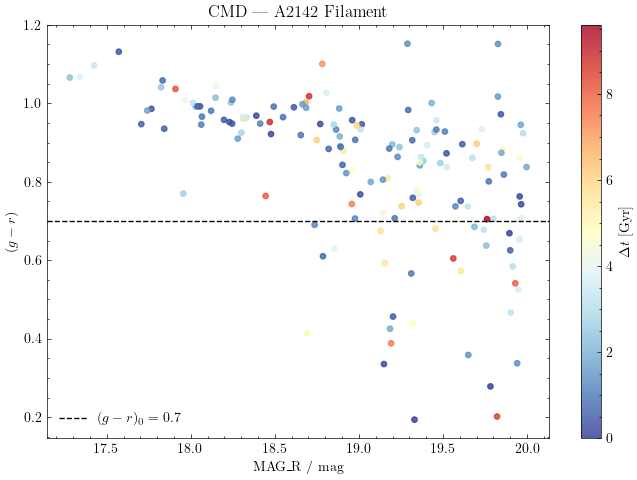

In [13]:
g_minus_r = df['MAG_G'] - df['MAG_R']

fig, ax = plt.subplots(figsize=(7, 5))

sc = ax.scatter(df['MAG_R'], g_minus_r, 
                c=df['timesc'], cmap='RdYlBu_r', 
                s=15, alpha=0.8, vmin=0, vmax=df['timesc'].max())

ax.axhline(0.7, color='black', ls='--', lw=1.0, label='$(g-r)_0 = 0.7$')

cbar = fig.colorbar(sc, ax=ax)
cbar.set_label(r'$\Delta t$ [Gyr]')

ax.set_xlabel('MAG_R / mag')
ax.set_ylabel('$(g - r)$')
ax.set_title('CMD — A2142 Filament')
ax.legend()
plt.tight_layout()
plt.show()

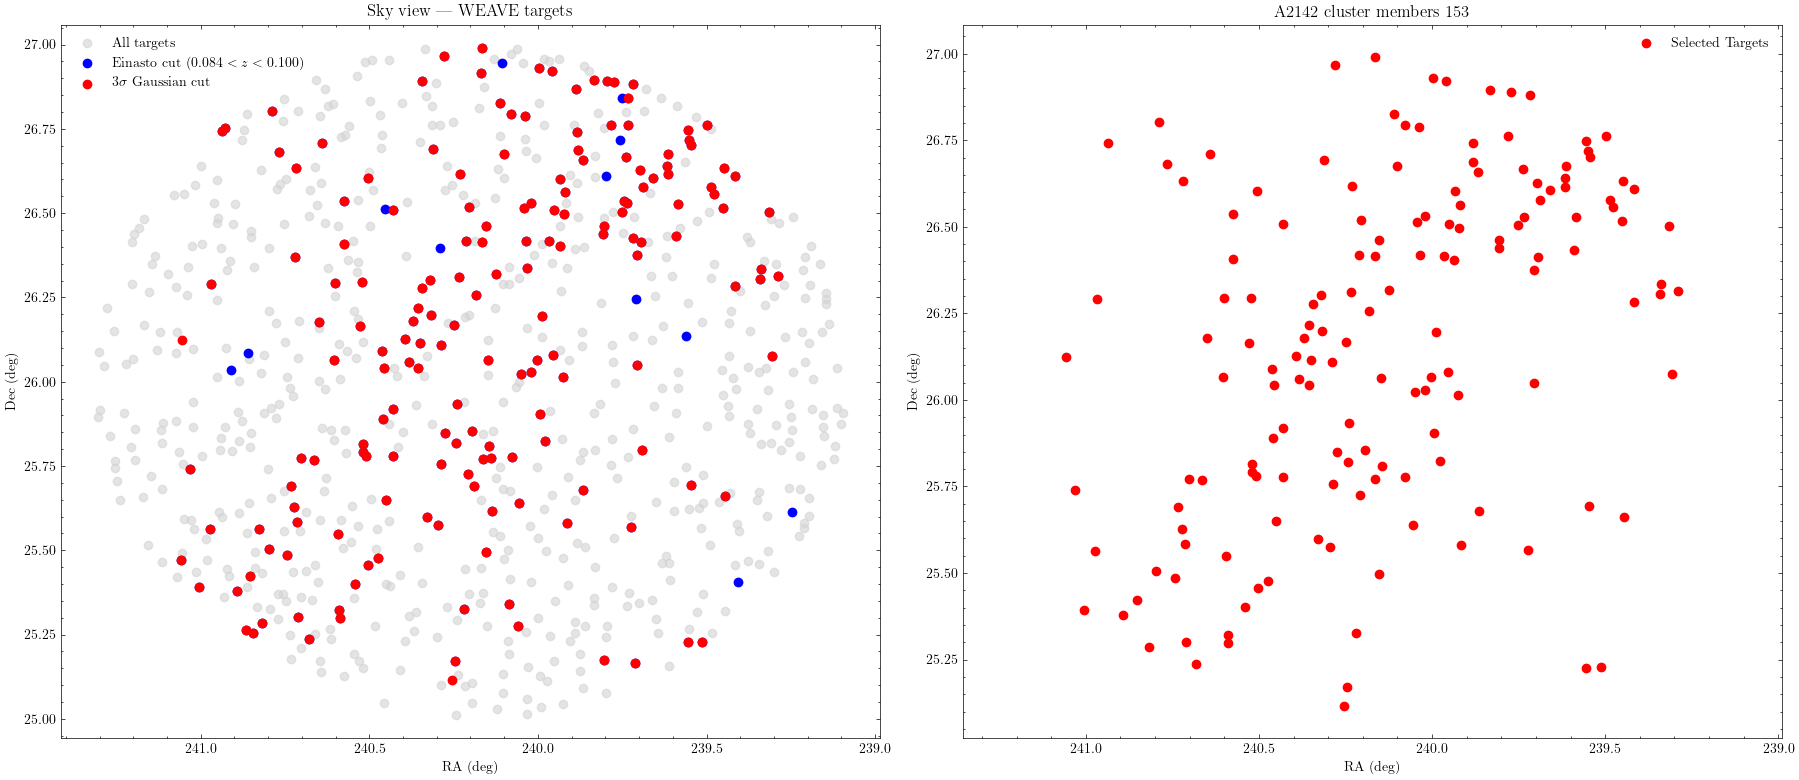

In [14]:
#--Sort Galaxies by Redshift--
einasto_cut = z_df[(z_df['Z_FINAL'] > 0.084) & (z_df['Z_FINAL'] < 0.100)]
gauss_cut = z_df[(z_df['Z_FINAL'] > 0.0828) & (z_df['Z_FINAL'] < 0.0948)]

fig, ax = plt.subplots(1, 2, figsize=(18, 8))

# --- Plot 1: all targets ---
ax[0].scatter(z_df['WEAVE_RA'], z_df['WEAVE_DEC'], c='lightgrey', label='All targets', zorder=1, alpha = 0.6)
ax[0].scatter(einasto_cut['WEAVE_RA'], einasto_cut['WEAVE_DEC'], c='blue', label=r'Einasto cut ($0.084 < z < 0.100$)', zorder=2)
ax[0].scatter(gauss_cut['WEAVE_RA'], gauss_cut['WEAVE_DEC'], c='red', label=r'$3\sigma$ Gaussian cut', zorder=3)
ax[0].set_xlabel('RA (deg)')
ax[0].set_ylabel('Dec (deg)')
ax[0].set_title('Sky view — WEAVE targets')
ax[0].invert_xaxis()
ax[0].set_aspect('equal', adjustable='datalim')
ax[0].legend()

# --- Plot 2: A2142 cluster members ---
ax[1].scatter(df['WEAVE_RA'], df['WEAVE_DEC'], c='red', label=r'Selected Targets', zorder=1)
ax[1].set_xlabel('RA (deg)')
ax[1].set_ylabel('Dec (deg)')
ax[1].set_title(f"A2142 cluster members {len(df['WEAVE_RA'])}")
ax[1].invert_xaxis()
ax[1].set_aspect('equal', adjustable='datalim')
ax[1].legend()

plt.tight_layout()
plt.show()

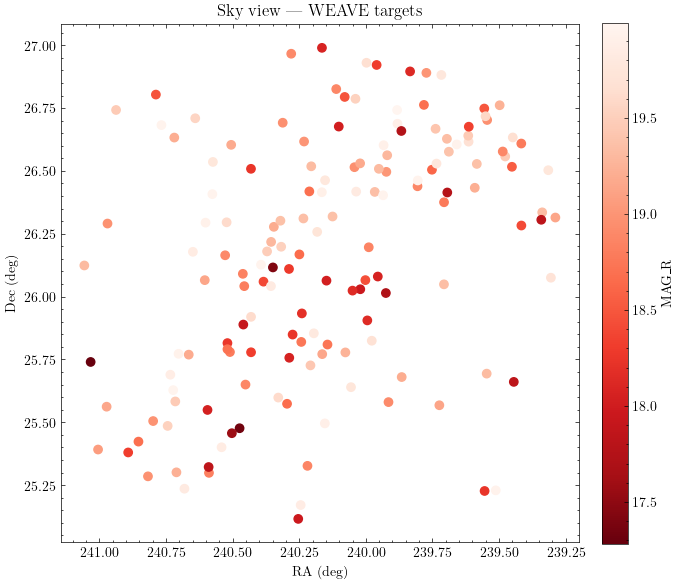

In [15]:
fig, ax = plt.subplots(figsize=(7, 7))

sc = ax.scatter(df['WEAVE_RA'], df['WEAVE_DEC'], 
                c=df['MAG_R'], cmap='Reds_r', zorder=3)
ax.set_box_aspect(1)
plt.colorbar(sc, ax=ax, label='MAG_R', fraction=0.046, pad=0.04)
ax.set_xlabel('RA (deg)')
ax.set_ylabel('Dec (deg)')
ax.set_title('Sky view — WEAVE targets')
ax.invert_xaxis()
plt.tight_layout()
plt.show()